In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from scipy.stats import norm
import matplotlib.pyplot as plt 
import seaborn as sns
import sys

sys.path.append("..")

from detection.detection import HMMDetectionEngine
from dataPipeline.fetchData import DataPipeLine 

# Load Data

tech_sector_df = pd.read_csv("../data/tech_sector_xlk.csv")
tech_sector_df["returns"] = tech_sector_df["close"].pct_change()
tech_sector_df.dropna(inplace=True)
tech_sector_df["log_returns"] = np.log(1 + tech_sector_df["returns"])

energy_sector_df = pd.read_csv("../data/energy_sector_xlx.csv")
energy_sector_df["returns"] = energy_sector_df["close"].pct_change()
energy_sector_df.dropna(inplace=True)
energy_sector_df["log_returns"] = np.log(1 + energy_sector_df["returns"]) 

/var/folders/s_/7m7l27gn2bs9lqs5gyg9_hnw0000gn/T/ipykernel_12958/3154000716.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


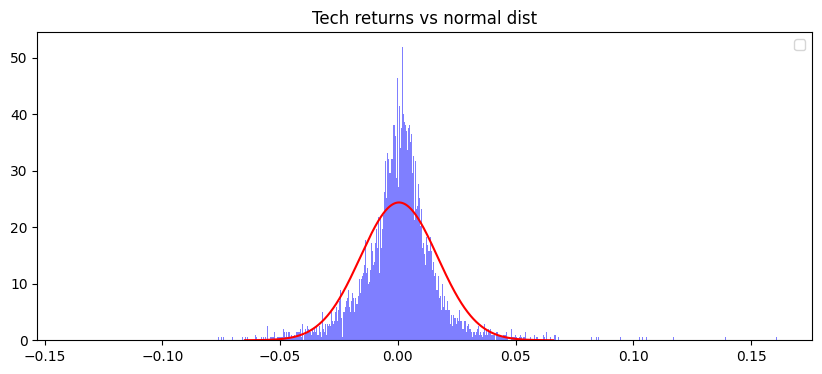

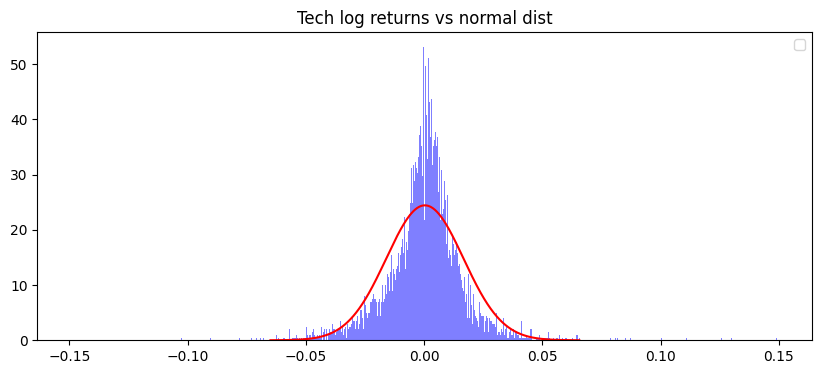

In [28]:
# Visualizing return, log returns and VaR
VaR_x = lambda df_series, percentile: -np.percentile(df_series, 100 - percentile)

def plot_against_normal(returns_series: pd.Series, title: str):
    plt.figure(figsize=(10,4))
    plt.hist(returns_series, bins=1000,
            color='blue', density=True, alpha=0.5)
    mu = returns_series.mean()
    sigma = returns_series.std()
    x = np.linspace(mu-4*sigma, mu+4*sigma, 1000)
    plt.plot(x, norm.pdf(x, mu, sigma),
            color='red',
            )
    plt.title(title)
    plt.legend()
    plt.show()

# with returns 
plot_against_normal(tech_sector_df["returns"], "Tech returns vs normal dist")

# with log returns
plot_against_normal(tech_sector_df["log_returns"], "Tech log returns vs normal dist")


Very inaccurate plots in the middle and near the tails.

skew: 0.08555554836327742, kurtosis: 9.919578791985558


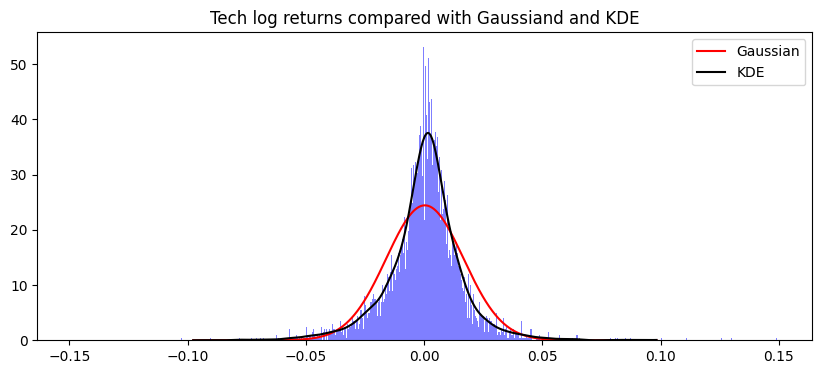

skew: 0.30825890553204943, kurtosis: 10.504490804050162


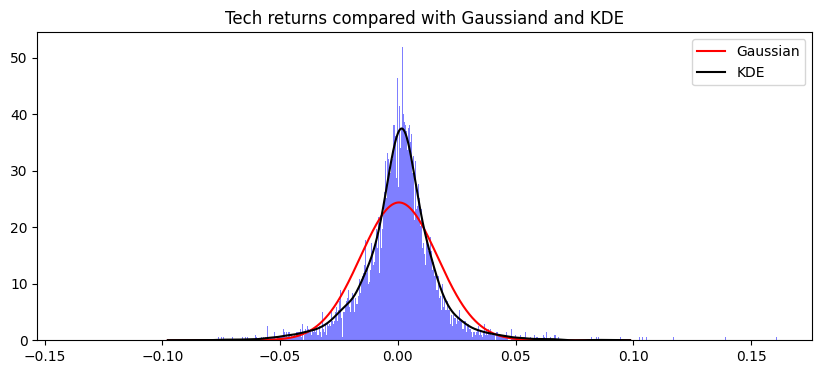

In [65]:
from scipy.stats import gaussian_kde, skew, kurtosis

def plot_with_noise(series:pd.Series, title:str):
    plt.figure(figsize=(10,4))
    plt.hist(series, bins=1000,
            color='blue', density=True, alpha=0.5)
    mu = series.mean()
    sigma = series.std()
    x = np.linspace(mu-6*sigma, mu+6*sigma, 1000)
    plt.plot(x, norm.pdf(x, mu, sigma),
            color='red', label="Gaussian"
            )
    
    kde = gaussian_kde(series.dropna())
    plt.plot(x, kde(x),
            color='black', label="KDE"
            )
    print(f"skew: {skew(series)}, kurtosis: {kurtosis(series, fisher=False)}")
    plt.title(title)
    plt.legend()
    plt.show()

    

plot_with_noise(tech_sector_df["log_returns"], f"Tech log returns compared with Gaussiand and KDE")
plot_with_noise(tech_sector_df["returns"], f"Tech returns compared with Gaussiand and KDE")



From the plots above, we could see that using KDE which estimates the distribution of the returns without assuming that it is Gaussian leads to a much more accurate estimation of the returns. However, the kurtosis is still not accurately captured. This estimation could be further enhanced using a regime switching model.

- The KDE pdf is slightly skewed compared to the normal
- Peak of KDE is much higher, more clustered towards the mean
- Difference in tails

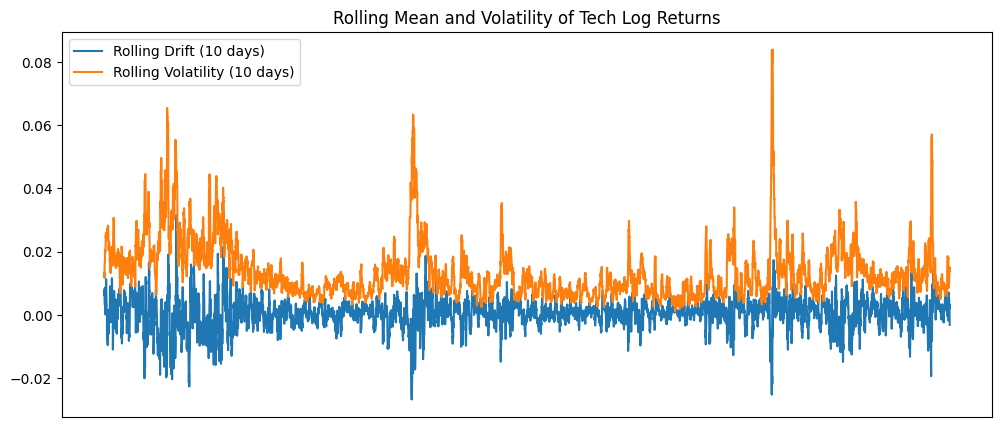

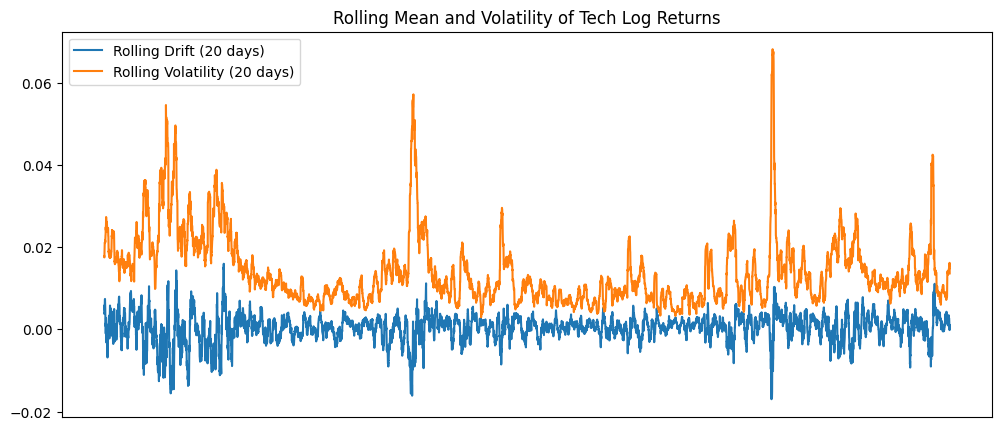

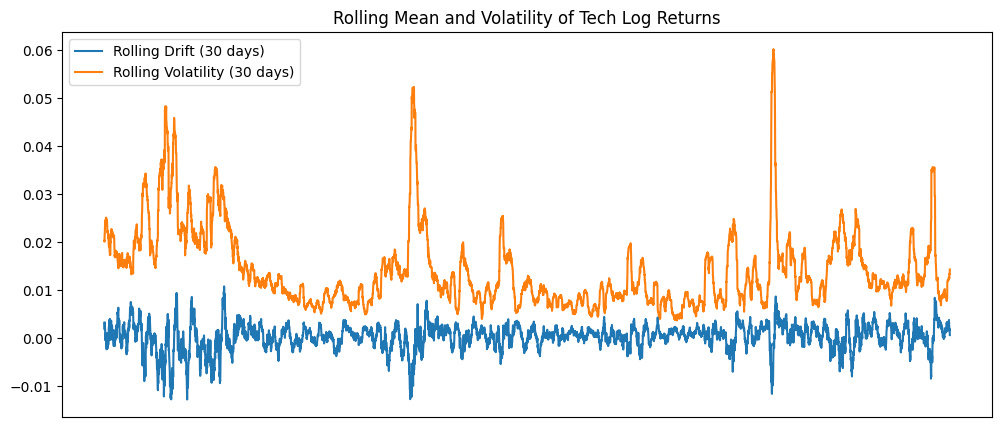

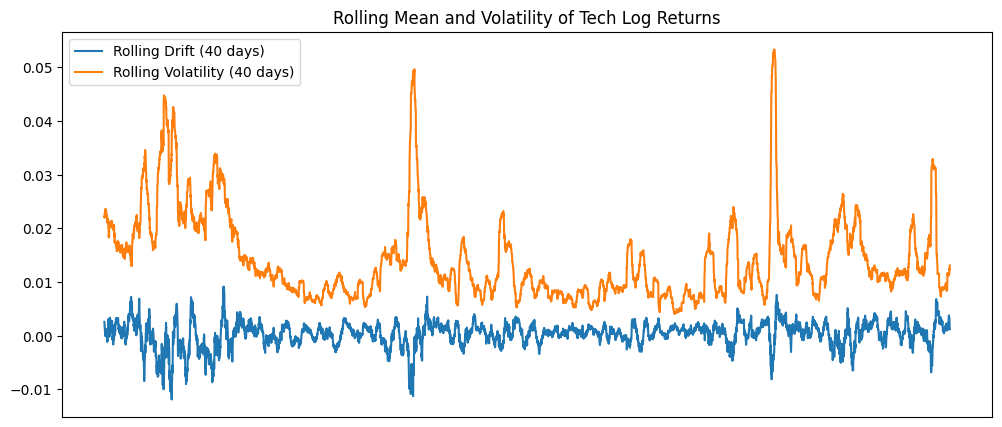

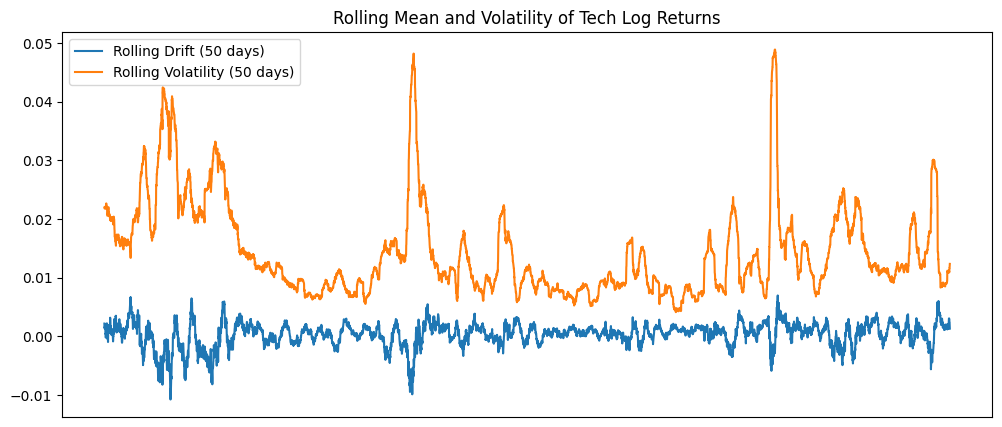

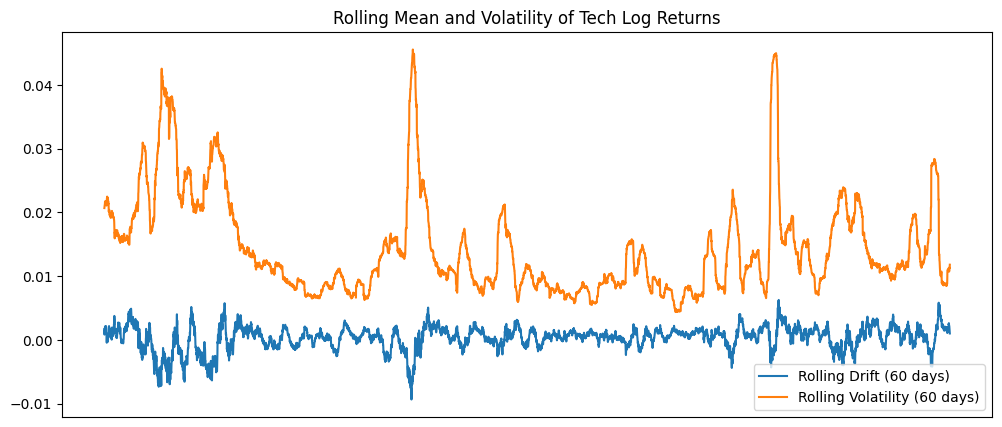

In [ ]:
def plot_rolling_stats(time_series: pd.Series, window_size: int):
    rolling_means = time_series.rolling(window=window_size).mean().dropna()
    rolling_vols = time_series.rolling(window=window_size).std().dropna()

    plt.figure(figsize=(12, 5))
    plt.plot(rolling_means, label=f"Rolling Drift ({window_size} days)")
    plt.plot(rolling_vols, label=f"Rolling Volatility ({window_size} days)")
    plt.title("Rolling Mean and Volatility of Tech Log Returns")
    plt.xticks([])
    plt.legend()
    plt.show()

for window in range(10, 70, 10):
    plot_rolling_stats(tech_sector_df["log_returns"], window)

With the plots above, it is very easy to see that there are periods of volatility and drift clustering, which hints that the XLK index moves in regimes. 

Next, we will run KDE on rolling windows to check if different time windows follow different distributions.

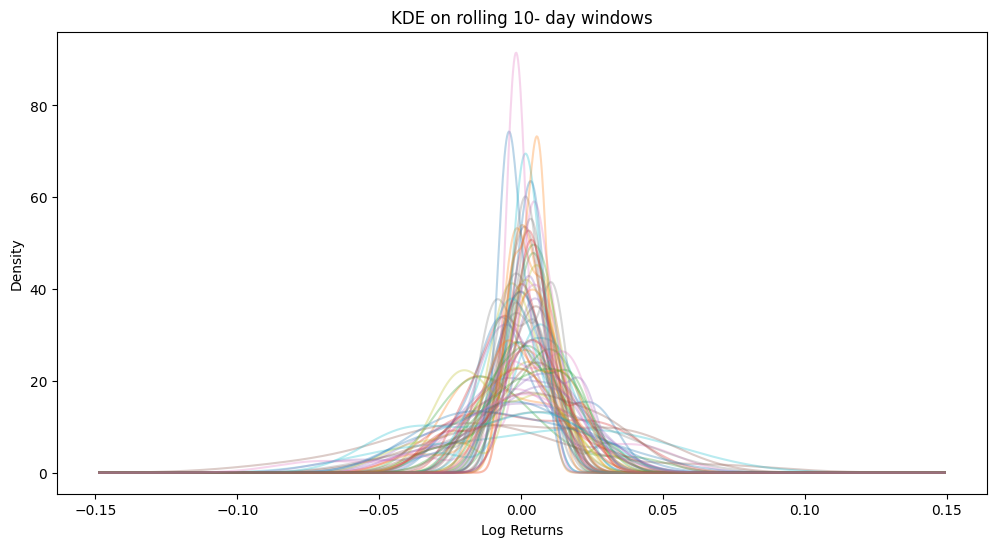

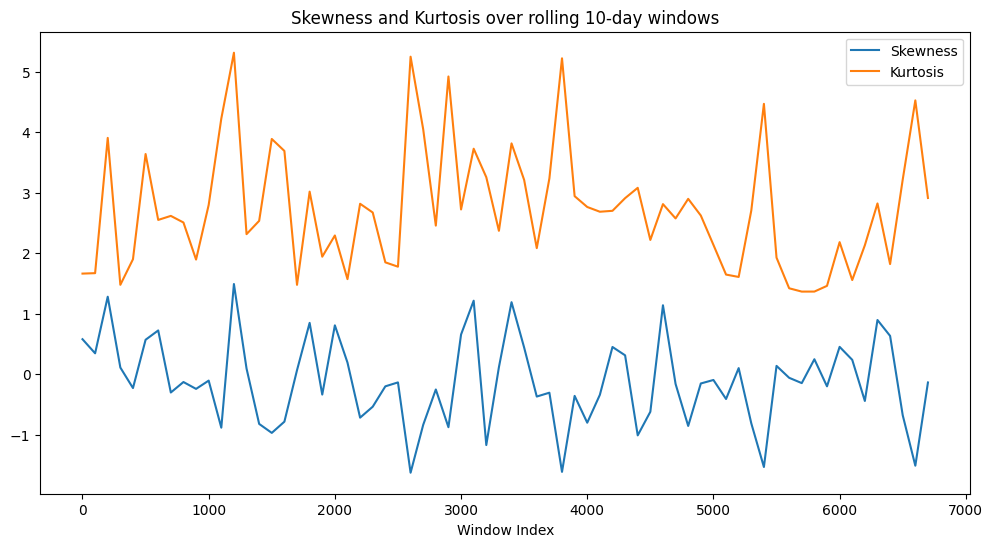

Average Skewness: -0.12493210691804035, Average Kurtosis: 2.730279949406527


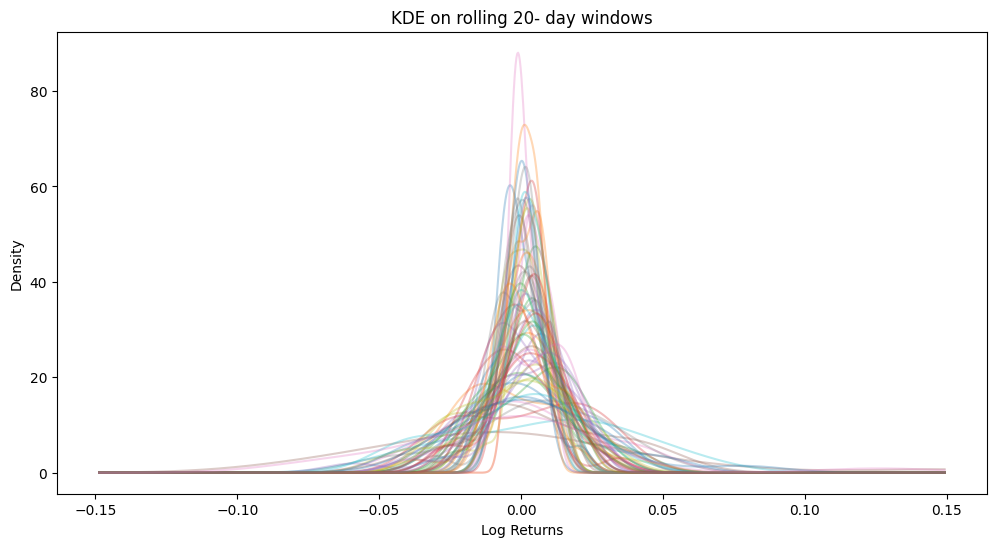

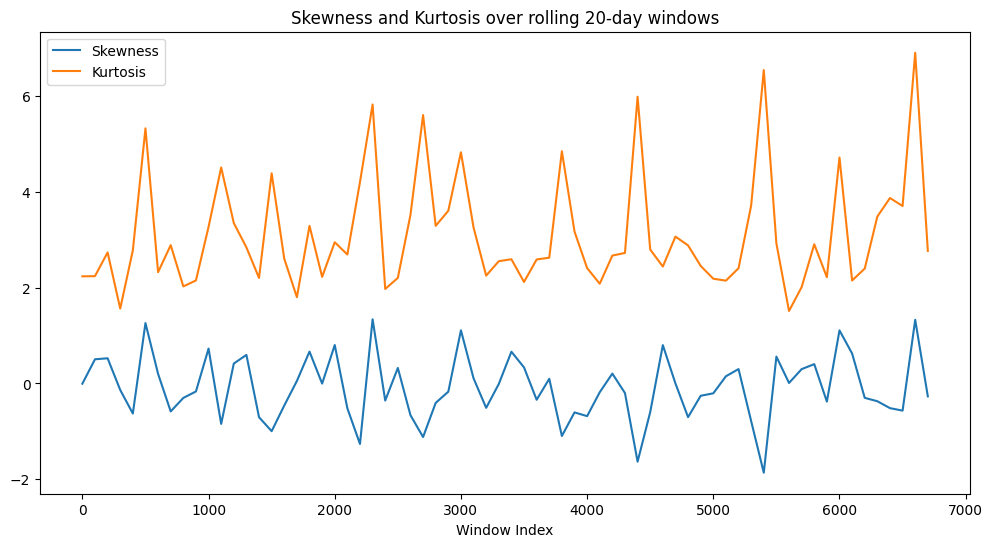

Average Skewness: -0.08662455586909948, Average Kurtosis: 3.1091519722783247


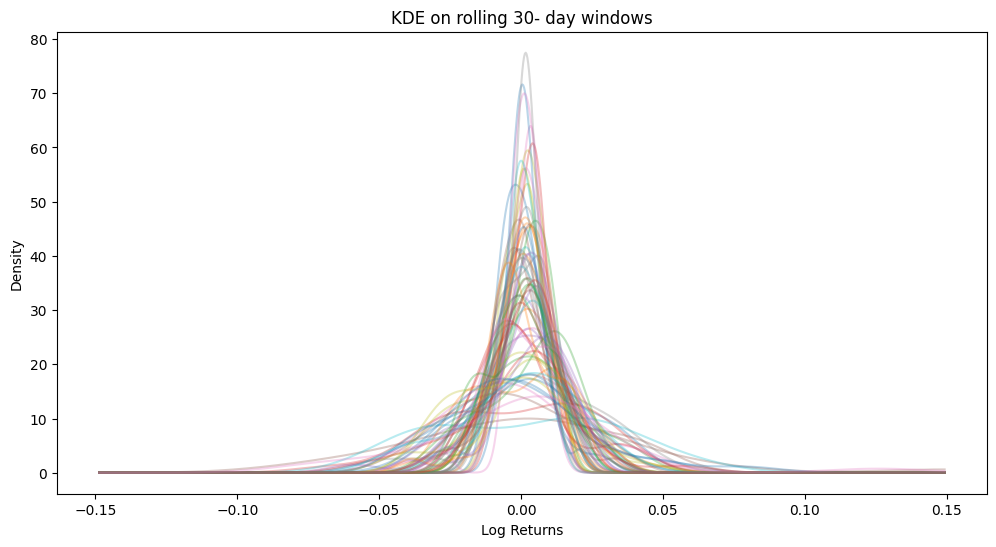

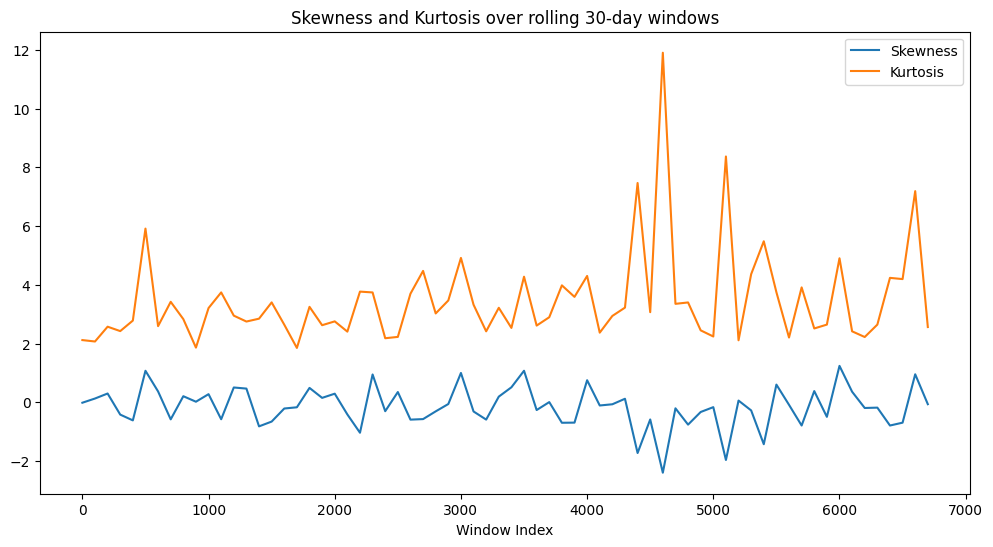

Average Skewness: -0.15052276480036525, Average Kurtosis: 3.4697256912718575


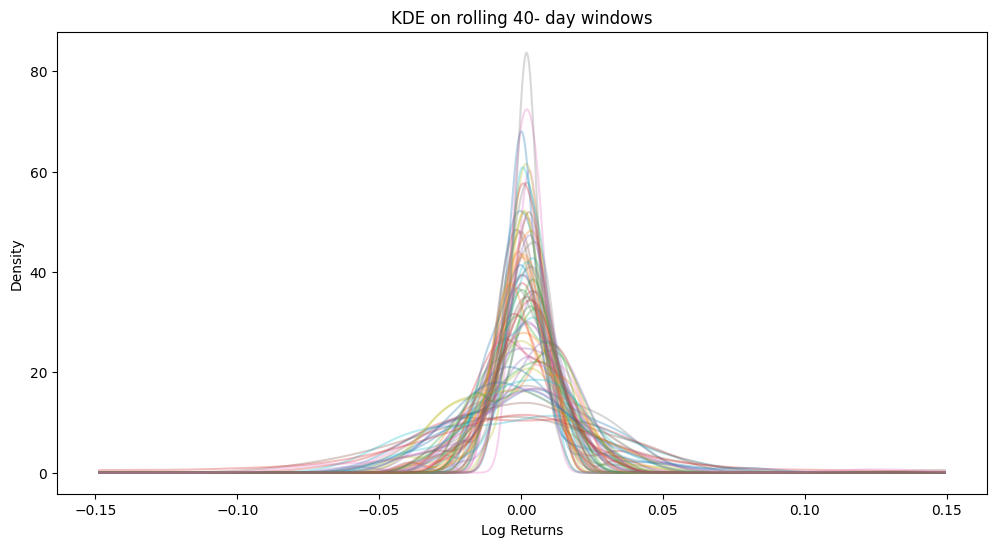

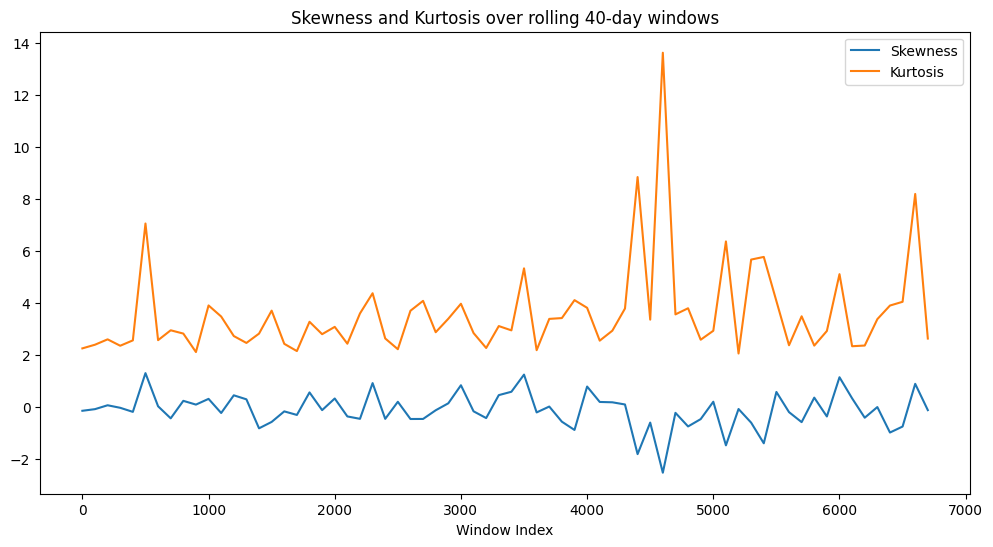

Average Skewness: -0.11800135310063847, Average Kurtosis: 3.5943884014077727


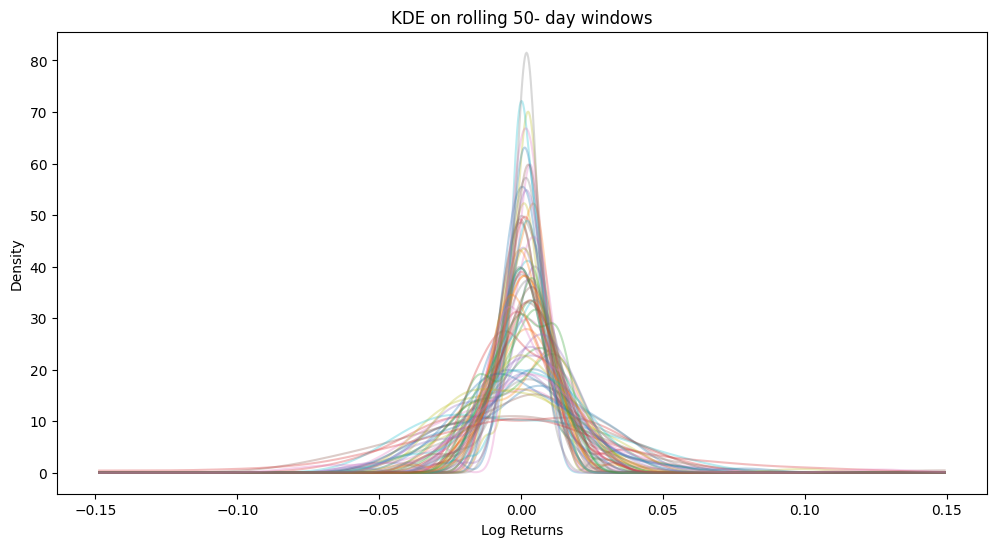

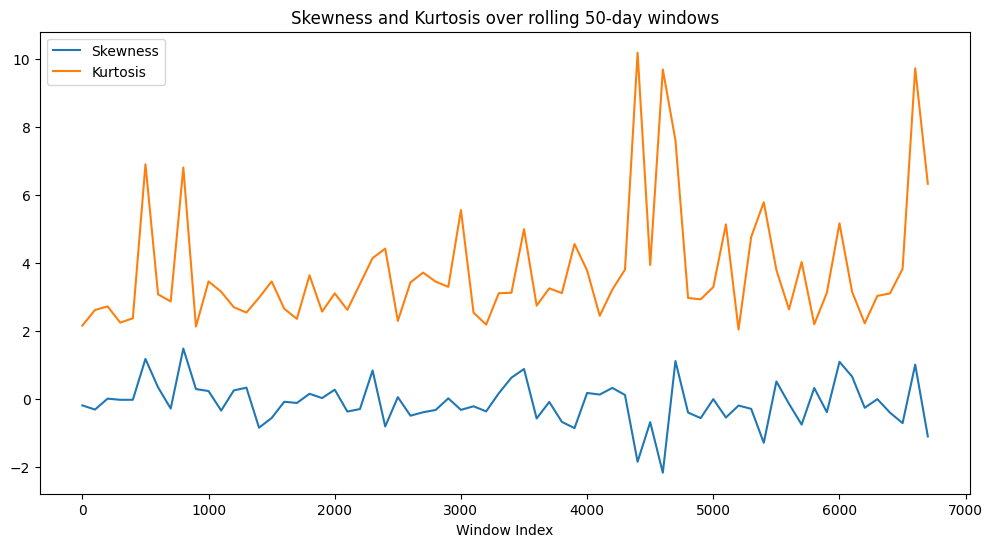

Average Skewness: -0.1034879109748531, Average Kurtosis: 3.774561836128795


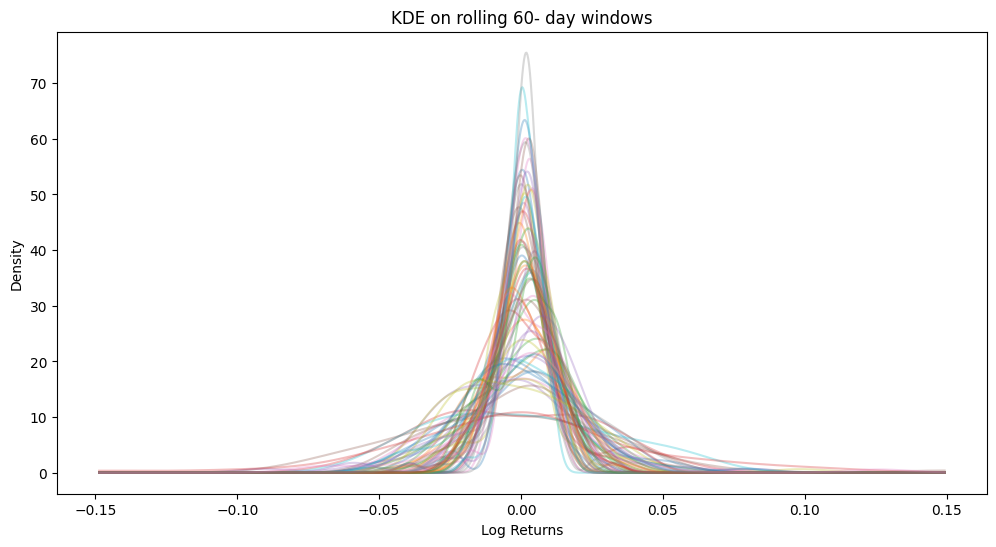

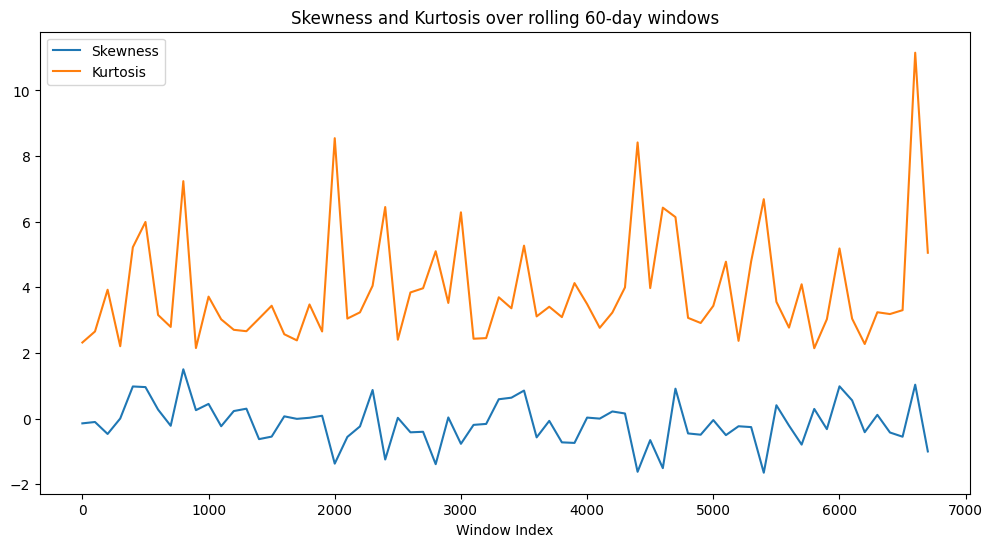

Average Skewness: -0.13696163375283646, Average Kurtosis: 3.932318225996366


In [76]:
def rolling_kde(time_series: pd.Series, window_size: int):
    n = len(time_series)
    x_min = time_series.min()
    x_max = time_series.max()
    x_grid = np.linspace(x_min, x_max, 1000)

    skews = []
    kurtoses = []

    plt.figure(figsize=(12, 6))
    plt.title(f"KDE on rolling {window_size}- day windows")

    # step is used since I don't want to plot each window
    for start in range(0, n - window_size + 1, step:=100):
        window_data = time_series[start:start + window_size].dropna()
        if len(window_data) < window_size:
            continue

        kde = gaussian_kde(window_data)
        plt.plot(x_grid, kde(x_grid), alpha=0.3)

        skews.append(skew(window_data))
        kurtoses.append(kurtosis(window_data, fisher=False))
    
    plt.xlabel("Log Returns")
    plt.ylabel("Density")
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(range(0, n - window_size + 1, step), skews, label="Skewness")
    plt.plot(range(0, n - window_size + 1, step), kurtoses, label="Kurtosis")
    plt.title(f"Skewness and Kurtosis over rolling {window_size}-day windows")
    plt.legend()
    plt.xlabel("Window Index")
    plt.show()
    print(f"Average Skewness: {np.mean(skews)}, Average Kurtosis: {np.mean(kurtoses)}")

for window in range(10, 61, 10):
    rolling_kde(tech_sector_df["log_returns"], window)
    
    

With these results, we could clearly see that different time windows follow very different
distributions, showing that this index does in fact move in regimes

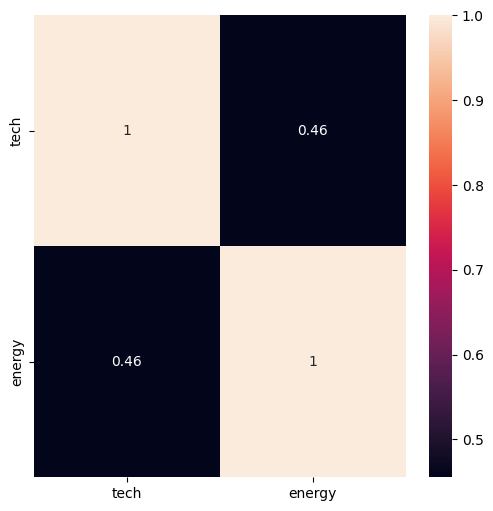

In [6]:
# correlation matrix

tech_returns = tech_sector_df[["date","returns"]].rename(columns={"returns":"tech"})
energy_returns = energy_sector_df[["date","returns"]].rename(columns={"returns":"energy"})
merged_returns = pd.merge(tech_returns, energy_returns, on="date")
corr_matrix = merged_returns[["tech", "energy"]].corr()

plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True)
plt.show()